In [23]:
import pandas as pd
from datasets import load_dataset
import json
from pprint import pprint

dataset = load_dataset("pagarsky/agent-trace")
traces = dataset["train"]

parsed_traces = []

# the dataset stores nested structures as JSON strings and the code converts them back into Python objects

for row in traces:
    parsed_traces.append({
        **row,
        "spans": json.loads(row["spans_json"]),
        "llm_steps": json.loads(row["llm_steps_json"]),
        "metadata": json.loads(row["metadata_json"]),
    })

In [24]:
rows = []

for trace in parsed_traces:
    for i, step in enumerate(trace["llm_steps"]):

        reasoning = step.get("reasoning_content") or ""

        if reasoning.strip():
            rows.append({
                "trace_id": trace["trace_id"],
                "model": trace["model"],
                "step_number": i,
                "entry": reasoning
            })

reasoning_df = pd.DataFrame(rows)

print("Reasoning entries:", len(reasoning_df))
reasoning_df.head()

Reasoning entries: 4029


,trace_id,model,step_number,entry
0,dc797f46-d2f2-453c-b5d3-3d8e761b395b,Qwen/Qwen3-0.6B,0,"Okay, I need to write a Python function to rem..."
1,5ce8ad22-6846-486b-9295-e88e0cbbeebe,Qwen/Qwen3-0.6B,0,"Okay, let's see. The user wants to write a fun..."
2,aad9576b-9be0-4e5b-897e-00354799fec6,Qwen/Qwen3-0.6B,0,"Okay, I need to write a function to count the ..."
3,aad9576b-9be0-4e5b-897e-00354799fec6,Qwen/Qwen3-0.6B,1,"Okay, let's see. The user wants a function to ..."
4,c02af7d8-b97b-442f-8c39-a1a9347dcd9f,Qwen/Qwen3-0.6B,0,"Okay, I need to write a Python function to fin..."


In [25]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = reasoning_df["entry"].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    normalize_embeddings=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

In [26]:
import faiss
import numpy as np

embeddings = np.asarray(embeddings).astype("float32")

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("Indexed vectors:", index.ntotal)

Indexed vectors: 4029


In [27]:
k = 6

similarities, indices = index.search(embeddings, k)

avg_similarity = similarities[:, 1:].mean(axis=1)

reasoning_df["avg_similarity"] = avg_similarity

reasoning_df["anomaly_score"] = 1 - avg_similarity

In [28]:
anomalies = reasoning_df.sort_values(
    "anomaly_score",
    ascending=False
)

anomalies[
    [
        "trace_id",
        "model",
        "step_number",
        "anomaly_score"
    ]
].head(20)

,trace_id,model,step_number,anomaly_score
204,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,9,0.689584
2653,68a2da48-dacd-4a83-80a5-901d717b642d,Qwen/Qwen3-0.6B,1,0.617395
3316,d375f259-edbb-4588-8b8c-622d92229331,Qwen/Qwen3-1.7B,9,0.447898
408,efc10fae-a122-4eb2-8bd4-a58e9c8da93f,Qwen/Qwen3-0.6B,0,0.432073
620,e2aae7a0-8742-40b5-93e9-aca1c7a9d656,Qwen/Qwen3-0.6B,0,0.429691
3202,3ee5d013-6e59-430a-a335-a6f2a8da3b4b,Qwen/Qwen3-1.7B,2,0.409160
2118,13c21450-22fd-4bb5-8bc6-6c273ebf1578,Qwen/Qwen3-1.7B,0,0.408504
3717,223e2946-f4e2-4a91-8f4f-bf395623422e,Qwen/Qwen3-1.7B,0,0.399442
3711,995ff4dc-0dbd-4627-b71a-1d8881cb2af1,Qwen/Qwen3-1.7B,2,0.393603
1470,b7294887-199d-4281-8dc1-2e11402b26cf,Qwen/Qwen3-1.7B,0,0.392864


In [29]:
anomalies = reasoning_df.sort_values(
    "anomaly_score",
    ascending=False
)

anomalies[
    [
        "trace_id",
        "model",
        "step_number",
        "anomaly_score"
    ]
].head(20)

,trace_id,model,step_number,anomaly_score
204,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,9,0.689584
2653,68a2da48-dacd-4a83-80a5-901d717b642d,Qwen/Qwen3-0.6B,1,0.617395
3316,d375f259-edbb-4588-8b8c-622d92229331,Qwen/Qwen3-1.7B,9,0.447898
408,efc10fae-a122-4eb2-8bd4-a58e9c8da93f,Qwen/Qwen3-0.6B,0,0.432073
620,e2aae7a0-8742-40b5-93e9-aca1c7a9d656,Qwen/Qwen3-0.6B,0,0.429691
3202,3ee5d013-6e59-430a-a335-a6f2a8da3b4b,Qwen/Qwen3-1.7B,2,0.409160
2118,13c21450-22fd-4bb5-8bc6-6c273ebf1578,Qwen/Qwen3-1.7B,0,0.408504
3717,223e2946-f4e2-4a91-8f4f-bf395623422e,Qwen/Qwen3-1.7B,0,0.399442
3711,995ff4dc-0dbd-4627-b71a-1d8881cb2af1,Qwen/Qwen3-1.7B,2,0.393603
1470,b7294887-199d-4281-8dc1-2e11402b26cf,Qwen/Qwen3-1.7B,0,0.392864


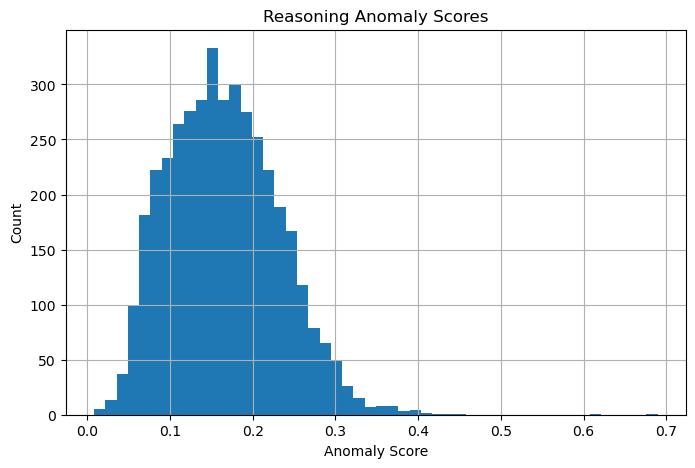

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

reasoning_df["anomaly_score"].hist(bins=50)

plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Reasoning Anomaly Scores")

plt.show()

In [30]:
trace_scores = (
    reasoning_df
    .groupby(["trace_id", "model"])
    .agg(
        max_anomaly=("anomaly_score", "max"),
        mean_anomaly=("anomaly_score", "mean"),
        steps=("step_number", "count")
    )
    .reset_index()
)

trace_scores.sort_values(
    "max_anomaly",
    ascending=False
).head(20)

,trace_id,model,max_anomaly,mean_anomaly,steps
1240,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,0.689584,0.265693,11
557,68a2da48-dacd-4a83-80a5-901d717b642d,Qwen/Qwen3-0.6B,0.617395,0.192649,11
1141,d375f259-edbb-4588-8b8c-622d92229331,Qwen/Qwen3-1.7B,0.447898,0.160238,11
1303,efc10fae-a122-4eb2-8bd4-a58e9c8da93f,Qwen/Qwen3-0.6B,0.432073,0.432073,1
1232,e2aae7a0-8742-40b5-93e9-aca1c7a9d656,Qwen/Qwen3-0.6B,0.429691,0.429691,1
331,3ee5d013-6e59-430a-a335-a6f2a8da3b4b,Qwen/Qwen3-1.7B,0.409160,0.135812,11
108,13c21450-22fd-4bb5-8bc6-6c273ebf1578,Qwen/Qwen3-1.7B,0.408504,0.408504,1
182,223e2946-f4e2-4a91-8f4f-bf395623422e,Qwen/Qwen3-1.7B,0.399442,0.381939,2
802,995ff4dc-0dbd-4627-b71a-1d8881cb2af1,Qwen/Qwen3-1.7B,0.393603,0.336864,3
994,b7294887-199d-4281-8dc1-2e11402b26cf,Qwen/Qwen3-1.7B,0.392864,0.392864,1


In [31]:
trace_id = "e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf"

trace = next(
    (t for t in parsed_traces if t["trace_id"] == trace_id),
    None
)

if trace is None:
    print("Trace not found")
else:
    print("Model:", trace["model"])
    print("Duration (s):", trace["total_duration_ms"] / 1000)
    print("LLM steps:", len(trace["llm_steps"]))
    print("Tool spans:", len(trace["spans"]))

Model: Qwen/Qwen3-0.6B
Duration (s): 1434.604061
LLM steps: 11
Tool spans: 0


In [32]:
for i, step in enumerate(trace["llm_steps"]):
    print("\n" + "=" * 80)
    print(f"STEP {i+1}")
    print("=" * 80)

    print("Output:")
    print(step.get("model_output"))

    print("\nReasoning:")
    print((step.get("reasoning_content") or "")[:5000])


STEP 1
Output:
Action:<think>
Okay, I need to write a function to count the same pair in three given lists. The test cases provided are expecting the results to be 3, 4, and 5 respectively. Let me think about how to approach this.

First, the problem says "same pair". So I guess that means each list should have elements that are the same, and we need to count how many such pairs exist. Wait, maybe the question is about pairs that are the same in each list? Or maybe the same elements across all three lists? The test cases are for three lists, so probably each list has elements that are the same, and we count how many pairs (i,j) where the elements are same in all three lists. 

For example, in the first test case, the lists are [1,2,3,4,5,6,7,8], [2,2,3,1,2,6,7,9], [2,1,3,1,2,6,7,9]. The pairs that are same would be (2,2) in the first and second list, and (2,2) in the first and third list. Wait, but how do we count that? Let me check.

The first test case's expected result is 3. Let's 

In [33]:
for i, span in enumerate(trace["spans"]):
    print("\n" + "=" * 80)
    print(f"TOOL SPAN {i+1}")
    print("=" * 80)

    print("Tool:", span.get("tool_name"))
    print("Duration (ms):", span.get("duration_ms"))
    print("Exit code:", span.get("exit_code"))

    print("\nInput:")
    print(span.get("tool_input"))

    print("\nOutput:")
    print(span.get("tool_output"))

In [34]:
import json

print(json.dumps(trace, indent=2))

{
  "trace_id": "e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf",
  "timestamp_utc": "2026-03-28T15:22:45.081465+00:00",
  "prompt": "Write a function to count the same pair in three given lists.\n\nTest cases:\nassert count_samepair([1,2,3,4,5,6,7,8],[2,2,3,1,2,6,7,9],[2,1,3,1,2,6,7,9])==3\nassert count_samepair([1,2,3,4,5,6,7,8],[2,2,3,1,2,6,7,8],[2,1,3,1,2,6,7,8])==4\nassert count_samepair([1,2,3,4,2,6,7,8],[2,2,3,1,2,6,7,8],[2,1,3,1,2,6,7,8])==5",
  "model": "Qwen/Qwen3-0.6B",
  "dataset_name": "mbpp",
  "task_id": 142,
  "run_id": "collect-0_6B-20260328T133144Z-mbpp",
  "total_duration_ms": 1434604.061,
  "tool_span_count": 0,
  "llm_step_count": 11,
  "spans_json": "[]",
  "llm_steps_json": "[{\"step_id\": \"bc163eab-7ad1-4b39-bd42-13b60153c00e\", \"step_number\": 1, \"model_output\": \"Action:<think>\\nOkay, I need to write a function to count the same pair in three given lists. The test cases provided are expecting the results to be 3, 4, and 5 respectively. Let me think about how to app

In [35]:
anomalies[anomalies["trace_id"] == trace_id]

,trace_id,model,step_number,entry,avg_similarity,anomaly_score
204,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,9,好的，用户多次遇到JSON格式错误，我需要仔细检查之前的步骤。首先，用户最初的问题是要计算三...,0.310416,0.689584
200,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,5,"Okay, the user is getting a JSON blob error ag...",0.651985,0.348015
203,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,8,"Okay, the user keeps getting the same JSON blo...",0.700725,0.299275
199,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,4,"Okay, the user is having an error in the JSON ...",0.748859,0.251141
202,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,7,"Okay, let's see. The user is getting a JSON bl...",0.754693,0.245307
198,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,3,"Okay, the user is getting a JSON blob error, w...",0.758451,0.241549
201,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,6,"Okay, the user keeps getting a JSON blob error...",0.776330,0.223670
197,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,2,"Okay, let's try to figure out the solution aga...",0.799344,0.200656
196,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,1,"Okay, I need to count the same pairs in three ...",0.847302,0.152698
195,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,0,"Okay, I need to write a function to count the ...",0.849089,0.150911


In [36]:
reasoning_df["trace_id"].value_counts().head(10)

trace_id
87cc8ca4-aa9e-44b5-9dda-f0e939a17830    11
8b7c7a42-48d1-42ce-9976-b48785f76e2a    11
f47da0f0-0281-43dd-9bac-221a417529db    11
4e45fef8-27a9-4c5b-ac0a-f02506e3f1a6    11
cb70acb6-1d98-4057-884a-e5c6da75f378    11
9938bd87-62c6-428c-a9db-3c94f394ca08    11
caf37884-853c-4ed7-9a97-a215248ac923    11
51bd15ee-96a3-4a6a-a6a9-e9f027bbb43e    11
431d2f92-70ea-45e3-af3e-4c480108c02f    11
a26ae7b2-e3b9-4392-a212-4a86dce78802    11
Name: count, dtype: int64

In [37]:
anomalies.head(30)["trace_id"].value_counts()

trace_id
223e2946-f4e2-4a91-8f4f-bf395623422e    2
f9053d26-eaec-4cee-b0ca-89f520544cc1    2
995ff4dc-0dbd-4627-b71a-1d8881cb2af1    2
d375f259-edbb-4588-8b8c-622d92229331    1
68a2da48-dacd-4a83-80a5-901d717b642d    1
e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf    1
efc10fae-a122-4eb2-8bd4-a58e9c8da93f    1
13c21450-22fd-4bb5-8bc6-6c273ebf1578    1
3ee5d013-6e59-430a-a335-a6f2a8da3b4b    1
e2aae7a0-8742-40b5-93e9-aca1c7a9d656    1
b7294887-199d-4281-8dc1-2e11402b26cf    1
f2839b99-708e-49b3-918b-94aae0e6314a    1
e5cd0fb3-bc9f-4ae4-9437-1d64f93f1048    1
2f79a94c-724b-49dd-8f35-d015d50fb74d    1
f15f37c9-0b4f-4dfc-a6c6-551a38f0744d    1
9888937e-cb73-4f12-bdf0-de7f0a1bf421    1
288c920e-076d-4a5a-a426-0ffd0b56102f    1
bce9e86d-d289-4e6c-9e76-b6a56a8ac71a    1
f89d121b-3fa6-4da4-821b-0e938093d682    1
7eb77c86-5bd7-419b-8c41-0ccb81836ef7    1
e4d5bdd3-fa7d-4a54-9fac-27cd520dadd5    1
c26a925a-d714-48e7-ae44-28c58bb9752c    1
f2d52607-223e-4398-96bd-f69ec00b9ca9    1
7644ce3a-a207-4d11-9591-4

In [38]:
trace_scores = (
    reasoning_df
    .groupby(["trace_id", "model"])
    .agg(
        max_anomaly=("anomaly_score", "max"),
        mean_anomaly=("anomaly_score", "mean"),
        n_steps=("step_number", "count")
    )
    .reset_index()
)

In [39]:
trace_scores.sort_values(
    "mean_anomaly",
    ascending=False
).head(20)

,trace_id,model,max_anomaly,mean_anomaly,n_steps
1303,efc10fae-a122-4eb2-8bd4-a58e9c8da93f,Qwen/Qwen3-0.6B,0.432073,0.432073,1
1232,e2aae7a0-8742-40b5-93e9-aca1c7a9d656,Qwen/Qwen3-0.6B,0.429691,0.429691,1
108,13c21450-22fd-4bb5-8bc6-6c273ebf1578,Qwen/Qwen3-1.7B,0.408504,0.408504,1
994,b7294887-199d-4281-8dc1-2e11402b26cf,Qwen/Qwen3-1.7B,0.392864,0.392864,1
1319,f2839b99-708e-49b3-918b-94aae0e6314a,Qwen/Qwen3-0.6B,0.389121,0.389121,1
1357,f9053d26-eaec-4cee-b0ca-89f520544cc1,Qwen/Qwen3-0.6B,0.390443,0.385733,2
182,223e2946-f4e2-4a91-8f4f-bf395623422e,Qwen/Qwen3-1.7B,0.399442,0.381939,2
1310,f15f37c9-0b4f-4dfc-a6c6-551a38f0744d,Qwen/Qwen3-0.6B,0.372239,0.372239,1
218,288c920e-076d-4a5a-a426-0ffd0b56102f,Qwen/Qwen3-0.6B,0.365689,0.365689,1
1026,bce9e86d-d289-4e6c-9e76-b6a56a8ac71a,Qwen/Qwen3-0.6B,0.363294,0.363294,1


In [40]:
trace_scores.sort_values(
    "max_anomaly",
    ascending=False
).head(20)

,trace_id,model,max_anomaly,mean_anomaly,n_steps
1240,e4f53892-e7b8-4be6-9c47-9cd2ad70fdaf,Qwen/Qwen3-0.6B,0.689584,0.265693,11
557,68a2da48-dacd-4a83-80a5-901d717b642d,Qwen/Qwen3-0.6B,0.617395,0.192649,11
1141,d375f259-edbb-4588-8b8c-622d92229331,Qwen/Qwen3-1.7B,0.447898,0.160238,11
1303,efc10fae-a122-4eb2-8bd4-a58e9c8da93f,Qwen/Qwen3-0.6B,0.432073,0.432073,1
1232,e2aae7a0-8742-40b5-93e9-aca1c7a9d656,Qwen/Qwen3-0.6B,0.429691,0.429691,1
331,3ee5d013-6e59-430a-a335-a6f2a8da3b4b,Qwen/Qwen3-1.7B,0.409160,0.135812,11
108,13c21450-22fd-4bb5-8bc6-6c273ebf1578,Qwen/Qwen3-1.7B,0.408504,0.408504,1
182,223e2946-f4e2-4a91-8f4f-bf395623422e,Qwen/Qwen3-1.7B,0.399442,0.381939,2
802,995ff4dc-0dbd-4627-b71a-1d8881cb2af1,Qwen/Qwen3-1.7B,0.393603,0.336864,3
994,b7294887-199d-4281-8dc1-2e11402b26cf,Qwen/Qwen3-1.7B,0.392864,0.392864,1
